In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import pandas as pd
df=pd.read_excel("/content/Global Cyber Threat Intelligence Dataset 2026.csv.xlsx")

In [ ]:
df.head()

,ip_address,abuse_confidence_score,country_code,last_reported_at,country_name,continent,reported_date,reported_year,reported_month,reported_day,reported_hour,reported_weekday,label,risk_level,severity,time_zone_attack
0,213.177.179.113,100,NL,2026-04-17 18:03:45+00:00,Netherlands,Europe,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening
1,172.94.9.48,100,NL,2026-04-17 18:03:45+00:00,Netherlands,Europe,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening
2,171.25.158.73,100,SE,2026-04-17 18:03:45+00:00,Sweden,Europe,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening
3,213.209.159.235,100,DE,2026-04-17 18:03:45+00:00,Germany,Europe,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening
4,163.53.168.23,100,CN,2026-04-17 18:03:45+00:00,China,Asia,2026-04-17,2026,4,17,18,Friday,Malicious,Critical,4,Evening


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ip_address              10000 non-null  object        
 1   abuse_confidence_score  10000 non-null  int64         
 2   country_code            10000 non-null  object        
 3   last_reported_at        10000 non-null  object        
 4   country_name            10000 non-null  object        
 5   continent               10000 non-null  object        
 6   reported_date           10000 non-null  datetime64[ns]
 7   reported_year           10000 non-null  int64         
 8   reported_month          10000 non-null  int64         
 9   reported_day            10000 non-null  int64         
 10  reported_hour           10000 non-null  int64         
 11  reported_weekday        10000 non-null  object        
 12  label                   10000 non-null  object 

In [ ]:
df.describe()

,abuse_confidence_score,reported_date,reported_year,reported_month,reported_day,reported_hour,severity
count,10000.0,10000,10000.0,10000.0,10000.0,10000.0,10000.0
mean,100.0,2026-04-17 00:00:00,2026.0,4.0,17.0,18.0,4.0
min,100.0,2026-04-17 00:00:00,2026.0,4.0,17.0,18.0,4.0
25%,100.0,2026-04-17 00:00:00,2026.0,4.0,17.0,18.0,4.0
50%,100.0,2026-04-17 00:00:00,2026.0,4.0,17.0,18.0,4.0
75%,100.0,2026-04-17 00:00:00,2026.0,4.0,17.0,18.0,4.0
max,100.0,2026-04-17 00:00:00,2026.0,4.0,17.0,18.0,4.0
std,0.0,NaN,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.columns = df.columns.str.strip().str.lower()

In [ ]:
df.isnull().sum()

,0
ip_address,0
abuse_confidence_score,0
country_code,0
last_reported_at,0
country_name,0
continent,0
reported_date,0
reported_year,0
reported_month,0
reported_day,0


In [ ]:
df=df.dropna()

In [ ]:
df['last_reported_at'] = pd.to_datetime(df['last_reported_at'])

In [ ]:
import pandas as pd
df=pd.read_excel("/content/Global Cyber Threat Intelligence Dataset 2026.csv.xlsx")

In [ ]:
df['abuse_confidence_score'] = pd.to_numeric(df['abuse_confidence_score'], errors='coerce')
df['reported_year'] = df['reported_year'].astype(int)
df['reported_month'] = df['reported_month'].astype(int)
df['reported_day'] = df['reported_day'].astype(int)
df['reported_hour'] = df['reported_hour'].astype(int)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df['label'].unique()
df['risk_level'].unique()

array(['Critical'], dtype=object)

In [ ]:
df['label'] = df['label'].str.capitalize()
df['risk_level'] = df['risk_level'].str.capitalize()

In [ ]:
import numpy as np
df['country_name'] = df['country_name'].replace({'Unknown': np.nan})

In [ ]:
df['country_name'] = df['country_name'].replace({'Unknown': np.nan})

In [ ]:
def get_time_zone(hour):
    if 0 <= hour < 6:
        return 'Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

df['time_zone_attack'] = df['reported_hour'].apply(get_time_zone)

In [ ]:
df.describe()
df['time_zone_attack'].value_counts()

,count
time_zone_attack,
Evening,10000


In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)

In [ ]:
df = df[df['abuse_confidence_score'] <= 100]
df = df[df['reported_hour'] <= 23]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# optional styling
sns.set(style="whitegrid")

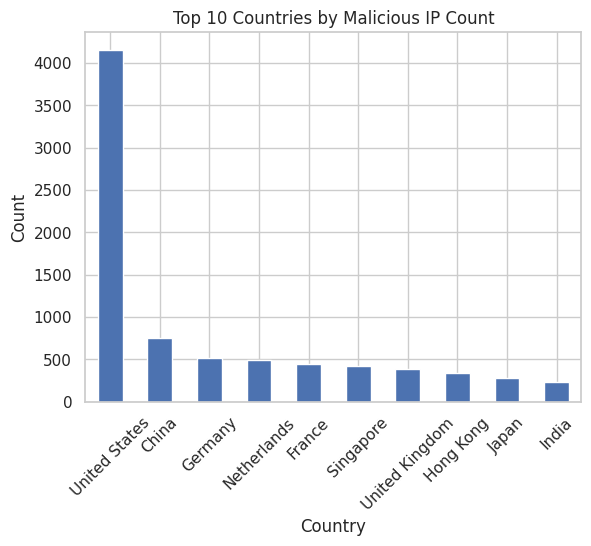

In [ ]:
top_countries = df['country_name'].value_counts().head(10)

plt.figure()
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Malicious IP Count")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

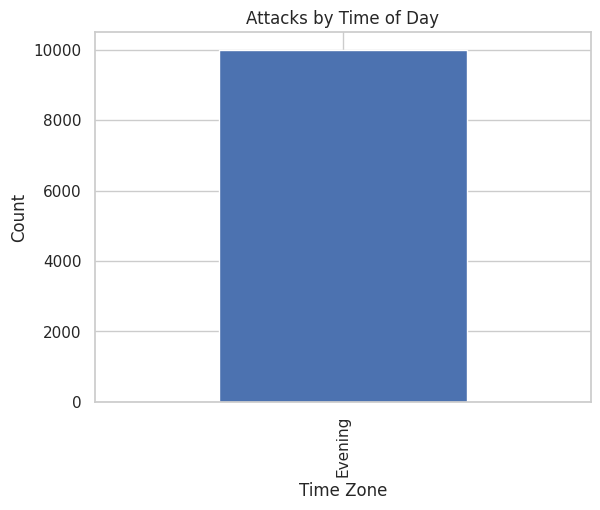

In [ ]:
time_zone_counts = df['time_zone_attack'].value_counts()

plt.figure()
time_zone_counts.plot(kind='bar')
plt.title("Attacks by Time of Day")
plt.xlabel("Time Zone")
plt.ylabel("Count")
plt.show()

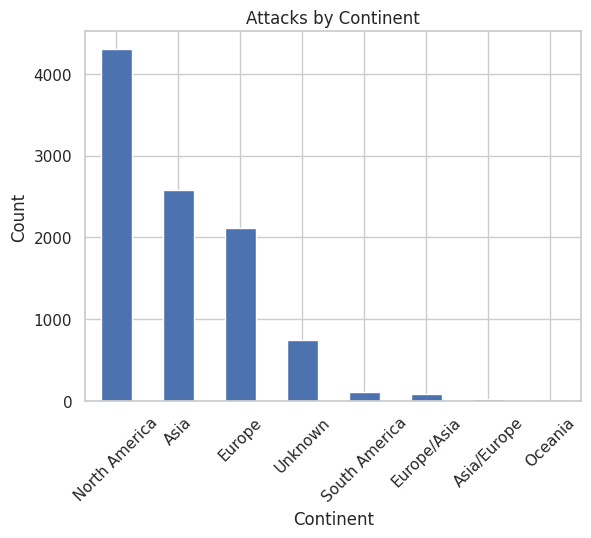

In [ ]:
continent_counts = df['continent'].value_counts()

plt.figure()
continent_counts.plot(kind='bar')
plt.title("Attacks by Continent")
plt.xlabel("Continent")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

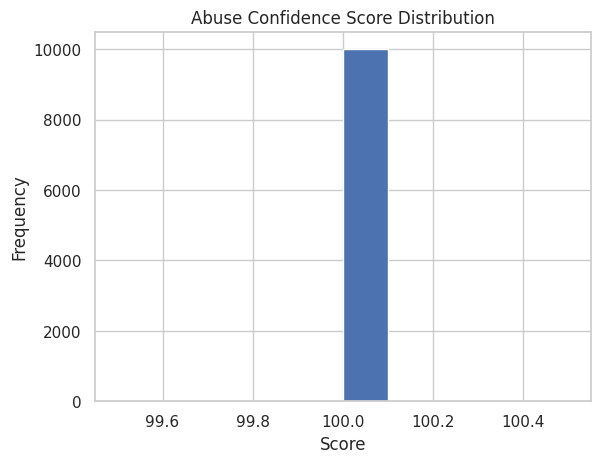

In [ ]:
plt.figure()
plt.hist(df['abuse_confidence_score'], bins=10)
plt.title("Abuse Confidence Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

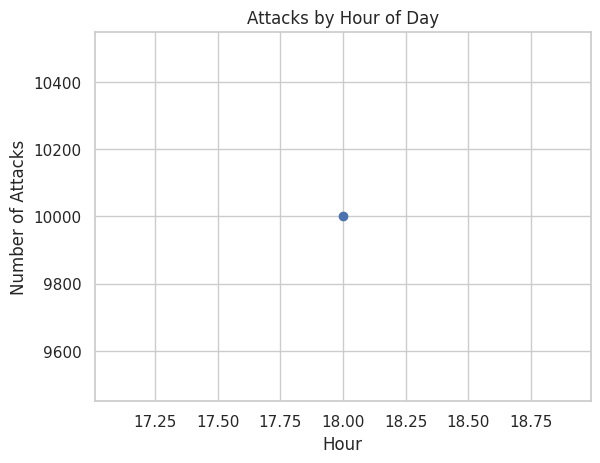

In [ ]:
hourly_attacks = df['reported_hour'].value_counts().sort_index()

plt.figure()
hourly_attacks.plot(kind='line', marker='o')
plt.title("Attacks by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Attacks")
plt.show()

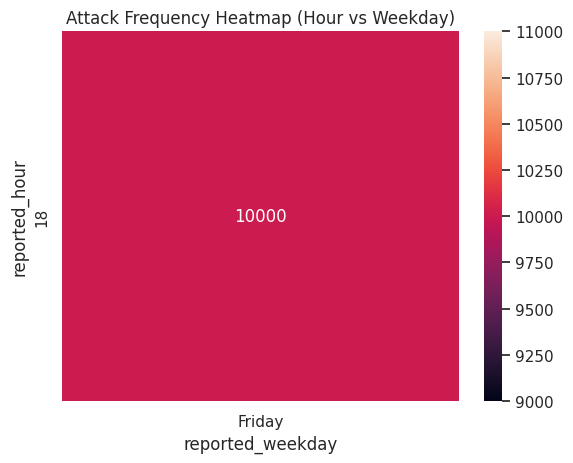

In [ ]:
pivot = df.pivot_table(index='reported_hour', columns='reported_weekday', aggfunc='size', fill_value=0)

plt.figure()
sns.heatmap(pivot, annot=True, fmt='d')
plt.title("Attack Frequency Heatmap (Hour vs Weekday)")
plt.show()

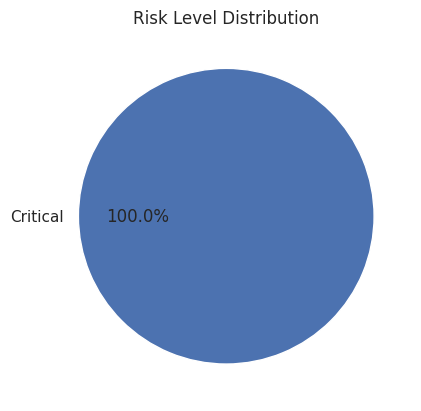

In [ ]:
risk_counts = df['risk_level'].value_counts()

plt.figure()
risk_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Risk Level Distribution")
plt.ylabel("")
plt.show()